In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-sentiment-twitter-corpus' dataset.
Path to dataset files: /kaggle/input/arabic-sentiment-twitter-corpus


In [2]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from nltk.corpus import stopwords
import nltk # Natural Language Toolkit
import string
from tqdm import tqdm
tqdm.pandas()
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC # Support Vector Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
os.listdir(path)

['train_Arabic_tweets_positive_20190413.tsv',
 'train_Arabic_tweets_negative_20190413.tsv',
 'test_Arabic_tweets_positive_20190413.tsv',
 'arabic_tweets',
 'test_Arabic_tweets_negative_20190413.tsv']

In [5]:
#1 read data #2 convert to dataframe #3 convert from tsv to csv
train_pos_dir = pd.read_csv(os.path.join(path , "train_Arabic_tweets_positive_20190413.tsv") , sep = "\t")
test_pos_dir = pd.read_csv(os.path.join(path , "test_Arabic_tweets_positive_20190413.tsv") , sep = "\t")
train_neg_dir = pd.read_csv(os.path.join(path , "train_Arabic_tweets_negative_20190413.tsv") , sep = "\t")
test_neg_dir = pd.read_csv(os.path.join(path , "test_Arabic_tweets_negative_20190413.tsv") , sep = "\t")

In [6]:
train_pos_dir.head()

,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لله، لا تبحثوا فينا عن قوة، إننا مكسورون، القوة التي…
0,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
1,pos,من الخير نفسه 💛
2,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
3,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
4,pos,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...


In [7]:
train_neg_dir.head()

,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم بالزايد 😭
0,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
1,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
2,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
3,neg,الدودو جايه تكمل علي 💔
4,neg,أحببته حتى أقنعنى إن ما فات من العمر كان إنتظا...


In [8]:
cols = ['Label' , 'Tweet']

train_pos_dir.columns = cols
test_pos_dir.columns = cols
train_neg_dir.columns = cols
test_neg_dir.columns = cols

In [9]:
train_df = pd.concat([train_pos_dir ,train_neg_dir] , ignore_index = True)
test_df = pd.concat([test_pos_dir , test_neg_dir] , ignore_index = True)

In [10]:
# Shuffle all rows (frac=1 → use 100% of data in random order)
# Reset index to 0..n and drop old messy index
train_data = train_df.sample(frac = 1).reset_index(drop = True)
test_data = test_df.sample(frac = 1).reset_index(drop = True)

In [11]:
print(train_data['Label'].value_counts())
print(test_data['Label'].value_counts())

Label
pos    22760
neg    22513
Name: count, dtype: int64
Label
neg    5767
pos    5751
Name: count, dtype: int64


In [12]:
train_data.head()

,Label,Tweet
0,neg,بعد كم سنه لح تشتهو تكونوا بشر ☝🏼 ترخولي التوي...
1,neg,لغز ما يحله إلا الذكي شديد الذكاء 🤔 نشط عقلك و...
2,pos,الهلال ينتصر .. لكنه بعيد جدا عن مستواه ! إهدا...
3,neg,يا اخوانا و الله لسة مطالبنا ما أتحقق منها غير...
4,pos,سحب على مبلغ مالي 💰 لمتابعي #كشكول 👍🏻 المطلوب:...


In [13]:
test_data.head()

,Label,Tweet
0,pos,الله يحفظكم ويوفقكم يارب لكم وحشة جميعا يالغال...
1,neg,انشهد الحزن من اول الليل 😭
2,neg,ميت ضحك 😭
3,neg,موقف الهلال القانوني قوي جدا وفضحهم وهو سبب اس...
4,pos,قوتنا بعد الله دائما أنتم🌹💙 الف مبرووك 💙 الحمد...


In [14]:
train_data.shape

(45273, 2)

In [15]:
test_data.shape

(11518, 2)

In [16]:
train_data.columns

Index(['Label', 'Tweet'], dtype='object')

In [17]:
print(train_data['Label'].unique())
print(test_data['Label'].unique())

['neg' 'pos']
['pos' 'neg']


In [18]:
train_data['Label'] = train_data['Label'].map({
    "pos" : 1,
    "neg" : 0
})

In [19]:
train_data.head()

,Label,Tweet
0,0,بعد كم سنه لح تشتهو تكونوا بشر ☝🏼 ترخولي التوي...
1,0,لغز ما يحله إلا الذكي شديد الذكاء 🤔 نشط عقلك و...
2,1,الهلال ينتصر .. لكنه بعيد جدا عن مستواه ! إهدا...
3,0,يا اخوانا و الله لسة مطالبنا ما أتحقق منها غير...
4,1,سحب على مبلغ مالي 💰 لمتابعي #كشكول 👍🏻 المطلوب:...


In [20]:
test_data['Label'] = test_data['Label'].map({
    "pos" : 1,
    "neg" : 0
})

In [21]:
test_data.head()

,Label,Tweet
0,1,الله يحفظكم ويوفقكم يارب لكم وحشة جميعا يالغال...
1,0,انشهد الحزن من اول الليل 😭
2,0,ميت ضحك 😭
3,0,موقف الهلال القانوني قوي جدا وفضحهم وهو سبب اس...
4,1,قوتنا بعد الله دائما أنتم🌹💙 الف مبرووك 💙 الحمد...


In [22]:
def check_language(text):
    if not isinstance(text, str): return "Empty"

    # Range for Arabic characters
    arabic_pattern = r'[\u0600-\u06FF]'
    # Range for English/Latin characters
    english_pattern = r'[a-zA-Z]'

    has_arabic = bool(re.search(arabic_pattern, text))
    has_english = bool(re.search(english_pattern, text))

    if has_arabic and has_english:
        return "Mixed"
    elif has_arabic:
        return "Arabic Only"
    elif has_english:
        return "English Only"
    else:
        return "Other"

# Apply it to your dataframe
train_data['Lang_Check'] = train_data['Tweet'].apply(check_language)

# See the distribution
print(train_data['Lang_Check'].value_counts())

Lang_Check
Arabic Only     43503
Mixed            1753
Other              15
English Only        2
Name: count, dtype: int64


In [23]:
nltk.download('stopwords')

arabic_stopwords = set(stopwords.words("arabic"))
english_stopwords = set(stopwords.words("english"))
all_stopwords = arabic_stopwords.union(english_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
exclude = string.punctuation
exclude

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [25]:
'''
.sub() → function meaning “substitute” (replace something with something else)
r'' → raw string (important for regex so backslashes \ work correctly)
http → matches URLs starting with http
\S → means “any non-space character”
+ → means “one or more”
http\S+ → matches full URL like http://abc.com
| → OR
www\S+ → matches URLs starting with www
\w → any word character (letters, numbers, _)
^ → means NOT (negation)
\u0600-\u06FF → Arabic characters Unicode range
a-zA-Z → English letters (small + capital)
\s → whitespace (space, tab, newline)
.strip() removes spaces from: beginning & end " hello " → "hello"
'''

def clean_tweets(text):

  # isinstance(text, str) Checks: is text actually a string? ✔ not Negation.
  if not isinstance(text , str):
    return ""

  # lowercase
  text = text.lower()

  # remove URLs
  text = re.sub(r'http\S+|www\S+' , '' , text)

  # remove mentions
  text = re.sub(r'@\w+' , '' , text)

  # remove hashtags symbol only
  text = re.sub(r'#' , '' , text)

  # Arabic Normalization
  text = re.sub(r"[اأإآ]" , "ا" , text)
  text = re.sub(r"ى" , "ي" , text)
  text = re.sub(r"ؤ" , "و" , text)
  text = re.sub(r"ئ" , "ي" , text)
  text = re.sub(r"ة" , "ه" , text)

  # remove Diacritics (التشكيل)
  text = re.sub(r'[\u064B-\u065F\u0617-\u061A\u06D6-\u06ED]' , '' , text)

  # remove digits
  text = re.sub(r'\d+' , '' , text)

  # remove HTML tags
  text = re.sub(r'<.*?>' , '' , text)

  # remove punctuation
  text = text.translate(str.maketrans('' , '' , exclude))

  # remove emojis + non Arabic/English chars
  text = re.sub(r'[^\u0600-\u06FFa-zA-Z\s]' , '' , text)

  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  # remove stopwords
  words = text.split()
  words = [w for w in words if w not in all_stopwords]


  return " ".join(words)

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4987/1389464595.py:3: SyntaxWarning: invalid escape sequence '\ '
  r'' → raw string (important for regex so backslashes \ work correctly)


In [26]:
print(arabic_stopwords)
len(arabic_stopwords)

{'قاطبة', 'لهم', 'لم', 'تينك', 'إنه', 'فوق', 'تجاه', 'تي', 'هلا', 'ق', 'أم', 'أينما', 'كيف', 'لئن', 'حزيران', 'أيلول', 'سحقا', 'ألا', 'هبّ', 'أيّان', 'كاف', 'عدا', 'هَذِي', 'كلاهما', 'فبراير', 'أخذ', 'أحد', 'بس', 'عامة', 'مع', 'صار', 'أمام', 'ليست', 'أ', 'صراحة', 'اللتيا', 'خلا', 'ذواتا', 'لما', 'ثمّة', 'تفعلان', 'هاكَ', 'هاتان', 'سبتمبر', 'ذهب', 'فيم', 'حمٌ', 'ثامن', 'تاسع', 'رويدك', 'علق', 'حاشا', 'بطآن', 'عشرون', 'مكانكنّ', 'بخٍ', 'مادام', 'خمس', 'منها', 'ستون', 'جير', 'تلك', 'سبع', 'ارتدّ', 'أما', 'لكنَّ', 'فإن', 'بعض', 'ثمّ', 'أمسى', 'دون', 'اثني', 'ولا', 'مرّة', 'كلما', 'أنا', 'مافتئ', 'بيد', 'ذات', 'حجا', 'هَاتَيْنِ', 'ثمانون', 'بخ', 'مئة', 'دينار', 'طفق', 'أربعمائة', 'طالما', 'هَاتِه', 'ى', 'ثلاثة', 'سرا', 'الذين', 'أصبح', 'ثلاثمئة', 'ج', 'صبر', 'أوّهْ', 'مذ', 'رابع', 'إليكم', 'همزة', 'لهن', 'تخذ', 'إلَيْكَ', 'اثنين', 'أجمع', 'تسعون', 'ثلاثمائة', 'أسكن', 'إلى', 'علًّ', 'لاسيما', 'هَيْهات', 'أصلا', 'درى', 'تبدّل', 'نعم', 'ديسمبر', 'ر', 'ذاك', 'حاء', 'الألى', 'اثنا', 'مكانَك', 'ه

701

In [27]:
print(english_stopwords)
len(english_stopwords)

{'these', 'having', 'from', 'have', 'before', 'them', 'during', 'can', 'hers', 'should', "isn't", 'both', 'such', "we'd", 'my', 'now', 'against', 'as', "should've", 'won', 'each', 'does', "needn't", "didn't", "i've", 'ours', "she's", 'was', 'to', 'don', 'his', 'more', 'of', 'or', 'because', 're', 'same', 'am', "it's", "they'd", 'is', 'doesn', 'between', 'it', 'aren', 'they', 'will', 'down', 'other', 'y', "you're", 'about', 'here', 'but', "wouldn't", 'wouldn', "we'll", "he'd", 'so', 'below', 'with', "it'll", 'ourselves', "wasn't", 'not', 'above', 'any', 'up', 'their', 'haven', 'll', 'through', 'ain', 'had', 'being', 'our', 'over', 'at', 'herself', 'off', "they've", 'who', "you'll", 'has', 'him', 'hadn', 'couldn', 'than', 'why', 'into', 'hasn', "couldn't", 'once', 'himself', 'whom', 'were', 'yourself', "i'd", "mightn't", "aren't", 'while', 'do', 'on', "i'm", 'no', 'her', 'wasn', 'under', 'very', 'yourselves', 'theirs', 'you', 'in', 'which', 'there', 'for', 'out', "haven't", 'm', 'be', "i

198

In [28]:
print(all_stopwords)
len(all_stopwords)

{'قاطبة', 'these', 'having', 'لهم', 'لم', 'have', 'تينك', 'إنه', 'during', 'فوق', 'تجاه', 'تي', 'هلا', 'ق', 'أم', 'أينما', 'كيف', 'لئن', 'حزيران', 'أيلول', 'سحقا', 'ألا', 'هبّ', 'أيّان', 'now', 'كاف', 'as', 'each', 'عدا', 'هَذِي', 'does', 'كلاهما', 'فبراير', 'أخذ', 'أحد', 'بس', 'عامة', 'of', 'مع', 'more', 'صار', 'أمام', 'ليست', 'أ', 'صراحة', 'اللتيا', 'خلا', 'ذواتا', 'لما', 'ثمّة', 'تفعلان', "they'd", 'هاكَ', 'هاتان', 'سبتمبر', 'ذهب', 'فيم', 'down', 'حمٌ', 'ثامن', 'تاسع', 'رويدك', "you're", 'علق', 'حاشا', 'بطآن', 'عشرون', "wouldn't", 'مكانكنّ', 'بخٍ', 'مادام', 'خمس', 'منها', 'ستون', 'جير', 'تلك', 'سبع', 'ارتدّ', 'أما', 'لكنَّ', 'فإن', 'بعض', 'not', 'ثمّ', 'أمسى', 'دون', 'اثني', 'above', 'any', 'ولا', 'مرّة', 'كلما', 'أنا', 'مافتئ', 'their', 'بيد', 'll', 'ذات', 'حجا', 'through', 'هَاتَيْنِ', 'ثمانون', 'بخ', 'مئة', 'دينار', 'طفق', 'being', 'أربعمائة', 'طالما', 'هَاتِه', 'ى', 'ثلاثة', 'سرا', 'الذين', 'أصبح', 'ثلاثمئة', 'ج', 'صبر', 'أوّهْ', 'were', 'yourself', 'مذ', 'رابع', 'إليكم', "i'd",

899

In [29]:
train_data['Tweet'] = train_data['Tweet'].progress_apply(clean_tweets)
test_data['Tweet'] = test_data['Tweet'].progress_apply(clean_tweets)

100%|██████████| 11518/11518 [00:00<00:00, 27605.00it/s]


In [30]:
train_data.head()

,Label,Tweet,Lang_Check
0,0,سنه لح تشتهو تكونوا بشر ترخولي التويت somazgheib,Mixed
1,0,لغز يحله الا الذكي شديد الذكاء نشط عقلك وفكر ج...,Arabic Only
2,1,الهلال ينتصر لكنه بعيد جدا مستواه اهدار غريب ل...,Arabic Only
3,0,اخوانا الله لسه مطالبنا اتحقق مطلب عليكم الله ...,Arabic Only
4,1,سحب علي مبلغ مالي لمتابعي كشكول المطلوب شي رتو...,Arabic Only


In [31]:
test_data.head()

,Label,Tweet
0,1,الله يحفظكم ويوفقكم يارب وحشه جميعا يالغاليين
1,0,انشهد الحزن اول الليل
2,0,ميت ضحك
3,0,موقف الهلال القانوني قوي جدا وفضحهم سبب استقال...
4,1,قوتنا الله دايما انتم الف مبرووك الحمد لله الشكر


In [32]:
x_train = train_data['Tweet']
y_train = train_data['Label']

x_test = test_data['Tweet']
y_test = test_data['Label']

In [33]:
# Term Frequency – Inverse Document Frequency
# It is a way to convert text into numbers based on how important a word is in a document compared to all documents.
# TF-IDF is a feature extraction technique
# So TF-IDF is:
# ✔ A feature extraction method for text
# ✔ Converts words → numerical vectors
'''
What each parameter means:
lowercase=True
→ converts text to lowercase before processing
tokenizer=None
→ use default tokenizer (splits words by spaces/punctuation)
stop_words=None
→ do NOT remove stopwords automatically
ngram_range=(1,1)
→ only single words (unigrams)
→ no bigrams like “not good”
max_features=None
→ use ALL words in dataset
vocabulary=None
→ TF-IDF will build vocabulary automatically
binary=False
→ uses frequency-based TF-IDF (not just 0/1)
'''
tfidf_vectorizer = TfidfVectorizer(
    lowercase = True,
    tokenizer = None,
    stop_words = None,
    ngram_range = (1,2),
    # With ngram_range=(1,2):
    # this, movie, is, not, good,
    # this movie, movie is, is not, not good
    max_features = None,
    vocabulary = None,
    binary = False
)

In [34]:
x_tr = tfidf_vectorizer.fit_transform(x_train)
x_te = tfidf_vectorizer.transform(x_test)

In [35]:
vocab = tfidf_vectorizer.get_feature_names_out()
vocab

array(['aar', 'ab', 'ab بذن', ..., 'یوم ولدت', 'ۿي', 'ۿي شييا'],
      dtype=object)

In [36]:
svm_model = LinearSVC()
svm_model.fit(x_tr , y_train) # Model learns: x_train → y_train
svm_pred = svm_model.predict(x_te) # Model receives: x_test → ??? (unknown labels) 👉 Model outputs: predicted labels

print("SVM Accuracy : " , accuracy_score(y_test , svm_pred))
print(classification_report(y_test , svm_pred))

SVM Accuracy :  0.7998784511199861
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      5767
           1       0.81      0.78      0.80      5751

    accuracy                           0.80     11518
   macro avg       0.80      0.80      0.80     11518
weighted avg       0.80      0.80      0.80     11518



<Axes: >

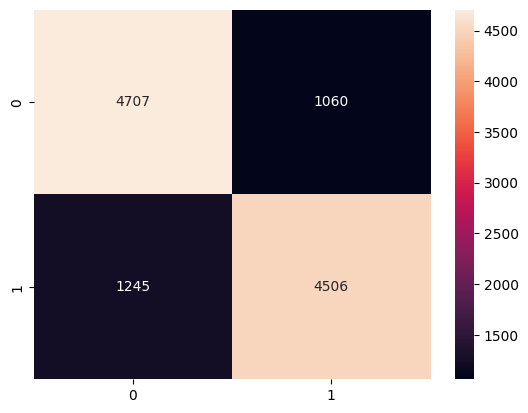

In [37]:
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [38]:
log_reg = LogisticRegression(max_iter = 1000) # max_iter=1000 👉 means: maximum training steps
log_reg.fit(x_tr , y_train)
log_pred = log_reg.predict(x_te)

print("Logistic Regression Accuracy : " ,accuracy_score(y_test , log_pred))
print(classification_report(y_test , log_pred))

Logistic Regression Accuracy :  0.7984893210626844
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      5767
           1       0.82      0.76      0.79      5751

    accuracy                           0.80     11518
   macro avg       0.80      0.80      0.80     11518
weighted avg       0.80      0.80      0.80     11518



<Axes: >

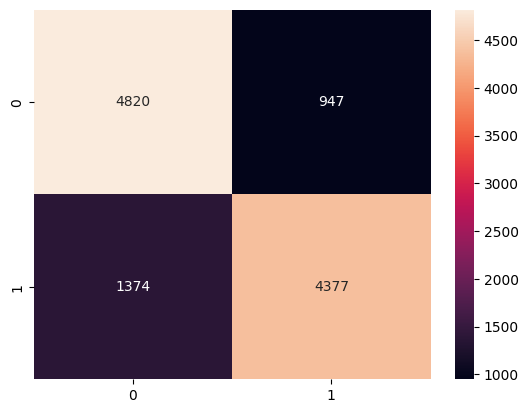

In [39]:
cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d')